In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [57]:
df = pd.read_csv('../data/kenya.csv', encoding='latin1')
print(df.shape)
df.head()

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [8]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14


Adding the country column

In [58]:
df["COUNTRY"] = "Kenya"
col = df.pop('COUNTRY')
df.insert(0, "COUNTRY", col)

Inserting a date column that converts, YEAR and DOY to a readable format

In [59]:
df['DATE'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format='%Y%j')

# saw this is another way to do it
# df['date'] = pd.to_datetime(df['YEAR'].astype(str) + df["DOY"].astype(str).str.zfill(3), format='%Y%j')

Inserting month column for seasonal analysis

In [61]:
df["MONTH"] = df["DATE"].dt.month

In [62]:
df.head()

,COUNTRY,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,Kenya,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,2015-01-01,1
1,Kenya,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,2015-01-02,1
2,Kenya,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,2015-01-03,1
3,Kenya,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,2015-01-04,1
4,Kenya,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,2015-01-05,1


Removing nasa's sentinel -999 with nan values

In [27]:
df = df.replace(-999, np.nan)

Counting duplicated rows

In [29]:
df.duplicated().sum()

0

Dropping duplicated rows

In [35]:
df = df.drop_duplicates()

#### Statistical summary

In [38]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,NaN,3.477046


#### Calculating percentages of missing values in each column

In [37]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_pct

COUNTRY        0.0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
date           0.0
DATE           0.0
MONTH          0.0
dtype: float64

#### Calculating Z-score

In [39]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

In [40]:
from scipy.stats import zscore

z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3).sum()
outliers

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

In [41]:
outlier_rows = df[(np.abs(z_scores) > 3).any(axis=1)]
len(outlier_rows)

132

#### Outlier Handling Decision

Retained outliers instead of removing them, The reason for this is that theu likely represent real extreme events (e.g., heatwaves, heavy rainfall)
Important for capturing climate variability and trends and invalid values (e.g., -999 sentinel values), were already removed earlier.

If there had been values that were impossible, like a Daily Temperature High of 200 degrees celcius, these whould have been removed. But I did not see such values.

#### Handling Missing Values by filling with previous value

In [43]:
df = df.fillna(method="ffill")

C:\Users\Liya Daniel\AppData\Local\Temp\ipykernel_13368\567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


Another approch to handle missing values, where missing values is greater than 30%

In [44]:
df = df.dropna(thresh=int(len(df.columns) * 0.7))

#### Exporting the dataframe 

In [46]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

## Time Series Analysis

#### Monthly average temperature

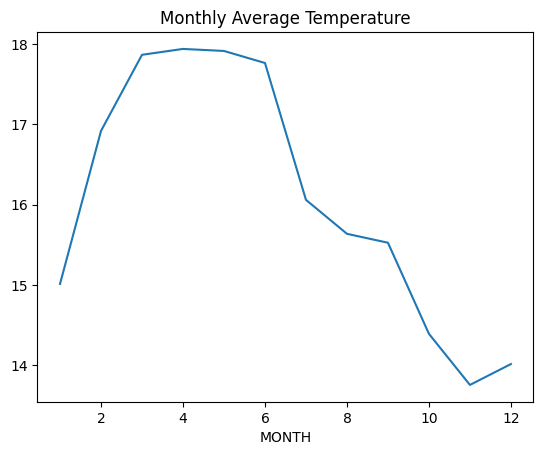

In [48]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

#### Box plot of Raninfall (prectotcorr)

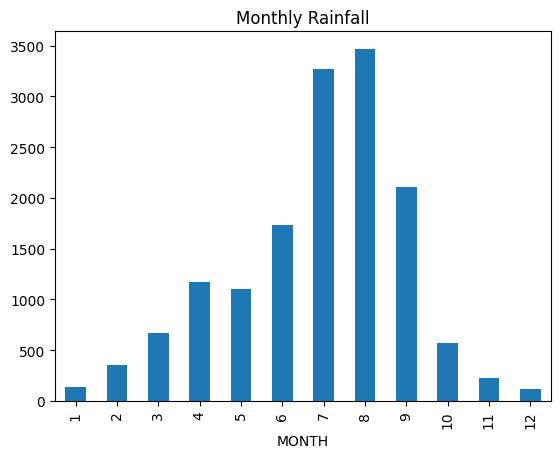

In [50]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

### Time Series Insights (Temperature & Rainfall)
The warmest months are March to June (Month 3–6), based on the highest average T2M values
These months show a consistent increase in temperature before peaking in early mid-year

The peak rainy season occurs between July and September (Month 7–9), based on total PRECTOTCORR
This period shows the highest rainfall accumulation, indicating a strong wet season pattern

Data shows a clear seasonal cycle, with hot and dry conditions earlier in the year and cooler, wetter conditions in mid-to-late year

## Correlation and Relationship Analysis

#### Heatmap of correlations across all numeric columns

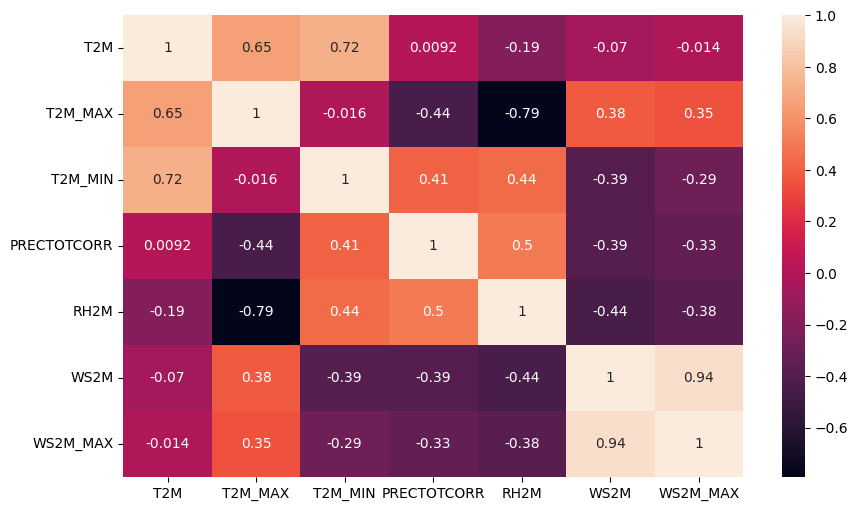

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True)
plt.show()

#### Scatter Plot (Mean Temperatue vs Relative Humidity)

<Axes: xlabel='T2M', ylabel='RH2M'>

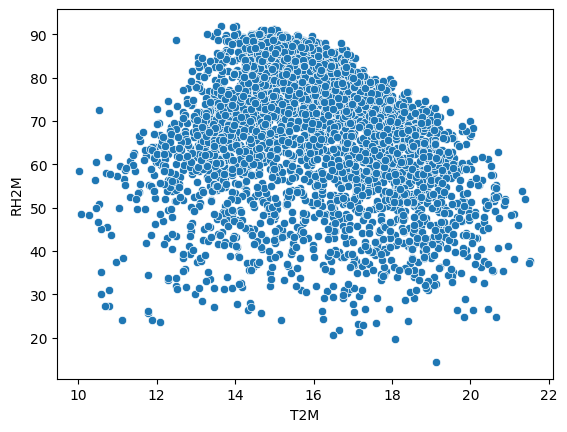

In [52]:
sns.scatterplot(data=df, x="T2M", y="RH2M")

#### Scatter Plot (Temperature range vs Windspeed)

<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

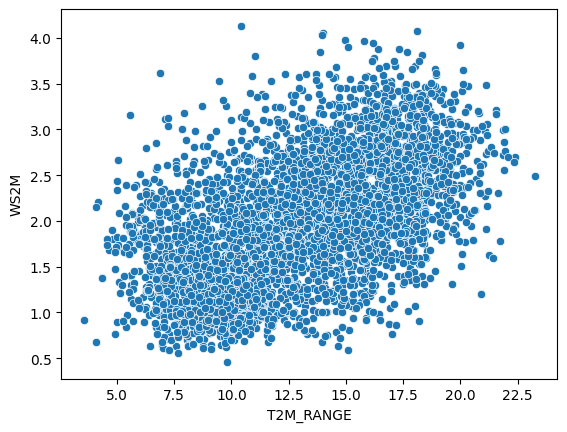

In [54]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

## Distribution Analysis

#### Histogram of Prectotcorr

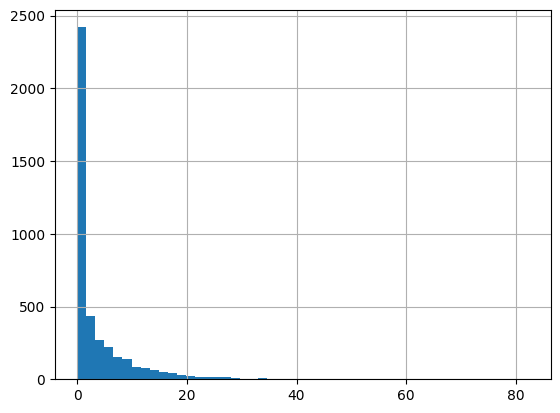

In [55]:
df["PRECTOTCORR"].hist(bins=50)
plt.show()

Highly right-skewed distribution of daily precipitation (PRECTOTCORR).
Vast majority of days have very low or zero rainfall, with a tall peak near 0 mm.

Rainfall amounts drop sharply after 5–10 mm, with very few days exceeding 20 mm.
Indicating a strong pattern of mostly dry days, interrupted by occasional moderate to heavy rain events.

#### Bubble Plot of Mean Temperature vs Relative Humidity and the size representing prectotcorr

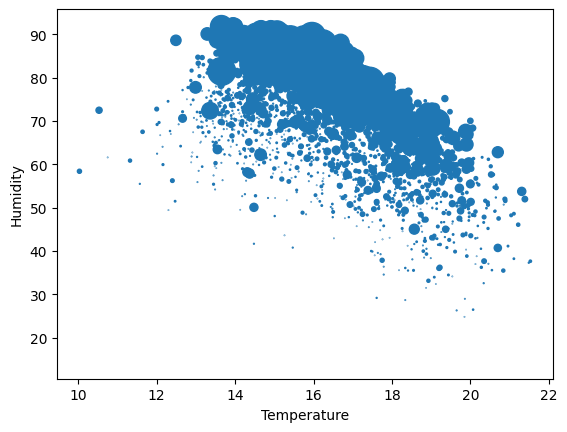

In [56]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()